In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import uproot
import itertools
from utils import *

np.random.seed(42)

In [2]:
SetStyle()

# After running FitDiagnostics, you can plot the postfit results using this Notebook. 

In [3]:
size = "l"
pred_type = "NP"
observable = "mass"
sort_type = "pt"
year = "2016"
signal_name = "dihiggs_dijet"
tag = "hh_sr23_signal"
datacard_path = "/pscratch/sd/v/vmikuni/CMSSW_14_1_0_pre4/NP/"
# Define which regiosn to write to datacards:
# SR: low tau21
# VR1: high tau21
# SR1: low tau21 + subleading jet mass > 100 GeV
# SR2: low tau21 + subleading jet mass < 100 GeV
# SR3: low tau21 + subleading jet mass > 100 GeV + at least one b-tagged jet
# SR4: low tau21 + at least one b-tagged jet
datacard_regions = ["SR3", "SR2", "VR1"]
# Binnings for different regions of interest
if observable == "dimass":
    bins = {
        "SR": np.linspace(1000, 1600, 15),
        "VR1": np.linspace(1000, 1600, 20),
        "SR1": np.linspace(1000, 1600, 16),
        "SR2": np.linspace(1000, 1600, 8),
    }
elif observable == "htag":
    bins = {
        "SR": np.linspace(60, 240, 20),
        "VR1": np.linspace(60, 240, 20),
        "SR1": np.linspace(60, 240, 18),
        "SR2": np.linspace(60, 235, 10),
    }
else:
    bins = {
        "SR": np.linspace(60, 240, 20),
        "VR1": np.linspace(60, 240, 20),
        "SR1": np.linspace(60, 240, 18),
        "SR2": np.linspace(60, 240, 7),
        "SR3": np.linspace(60, 240, 18),
        "SR4": np.linspace(60, 235, 10),
    }

mc_names = [
    "top_dijet",
    "ww_dijet",
    "wz_dijet",
    "zz_dijet",
    "higgs_dijet",
    "wjets_dijet",
    "zjets_dijet",
    "topw_dijet",
    "topz_dijet",
    "stopw_dijet",
    "stop_dijet",
]
if signal_name == "dihiggs_dijet":
    mc_names.append("dihiggs_dijet")

Path("plots").mkdir(parents=True, exist_ok=True)

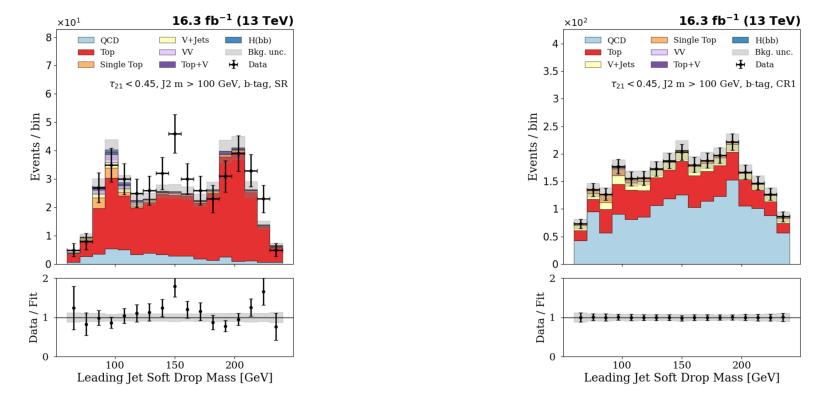

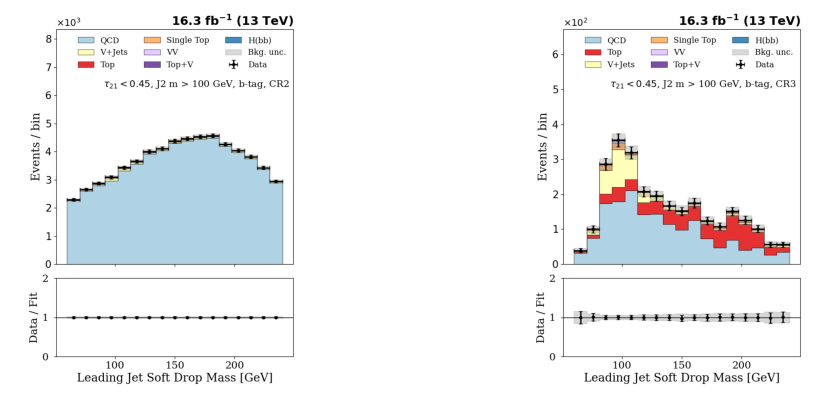

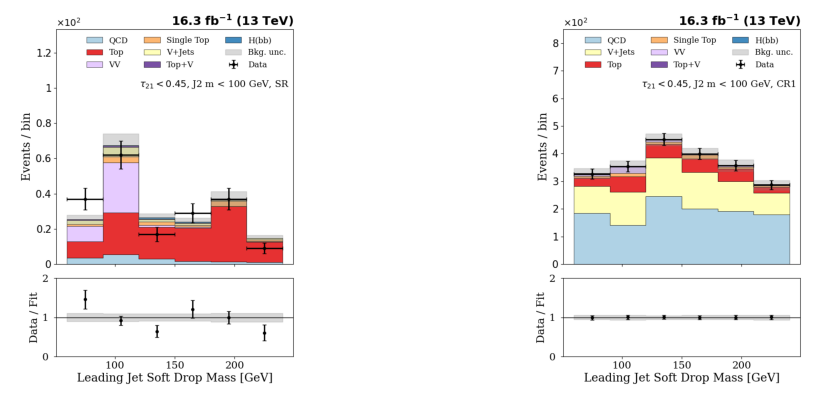

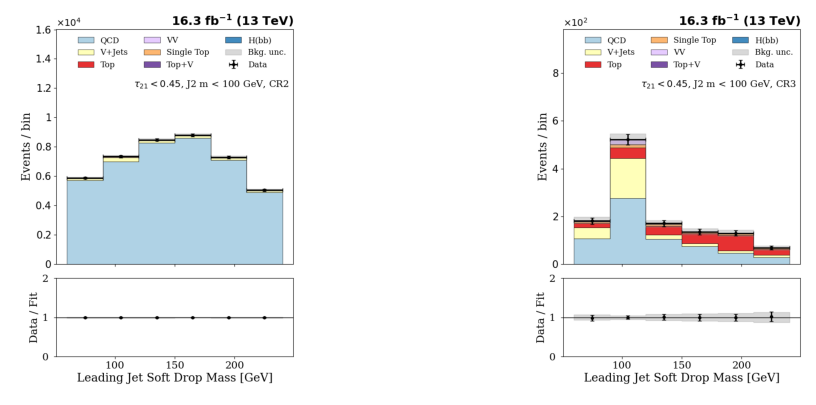

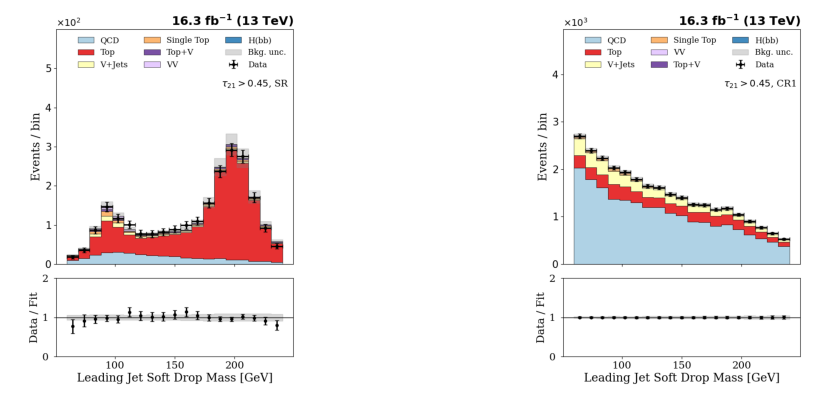

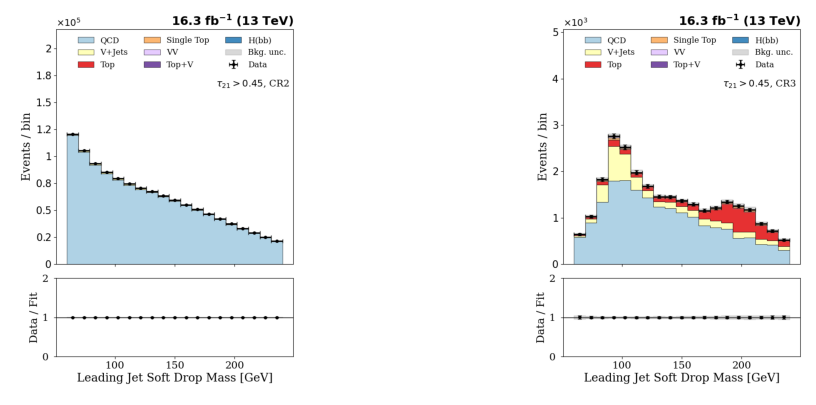

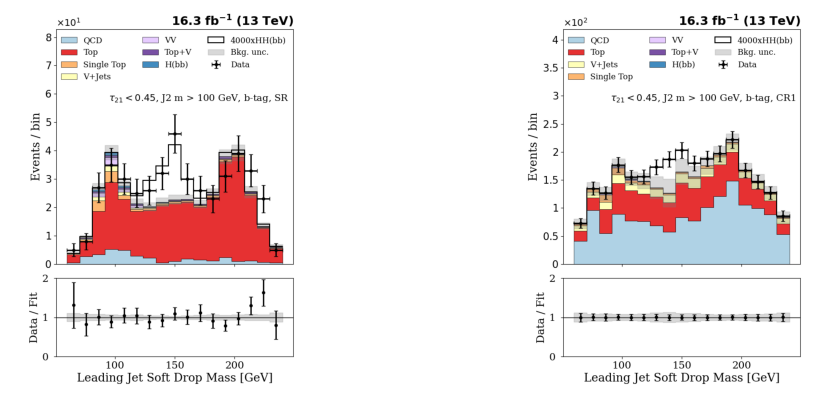

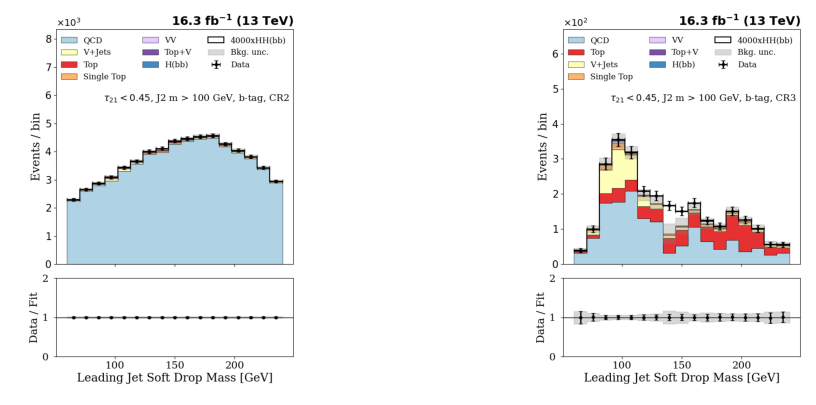

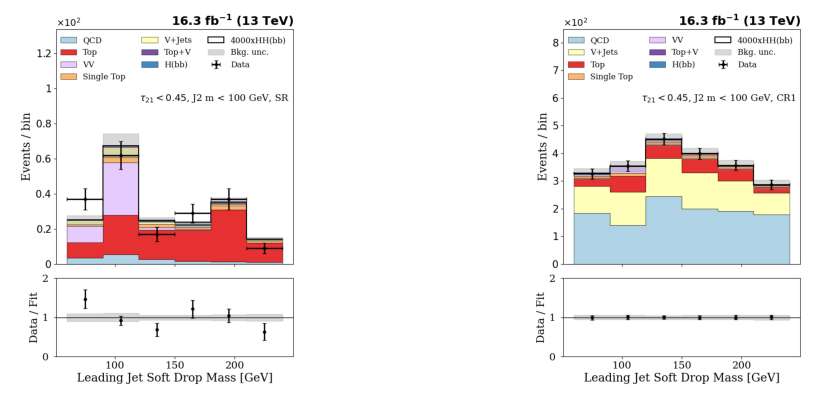

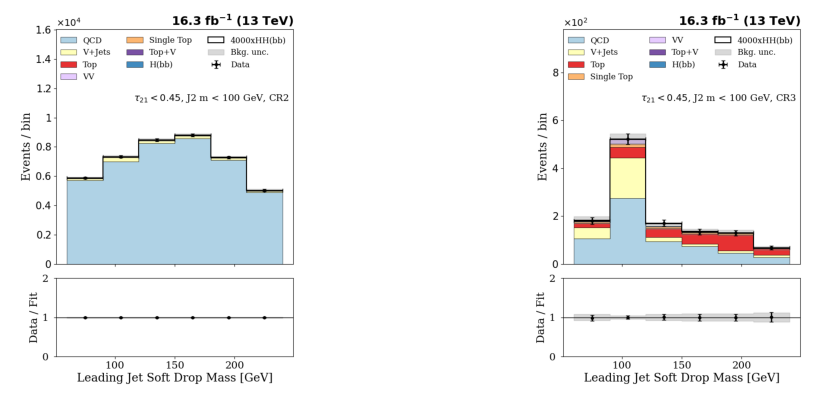

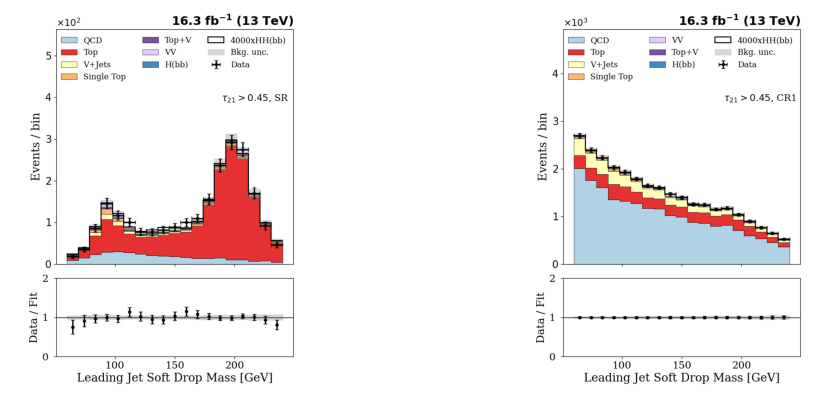

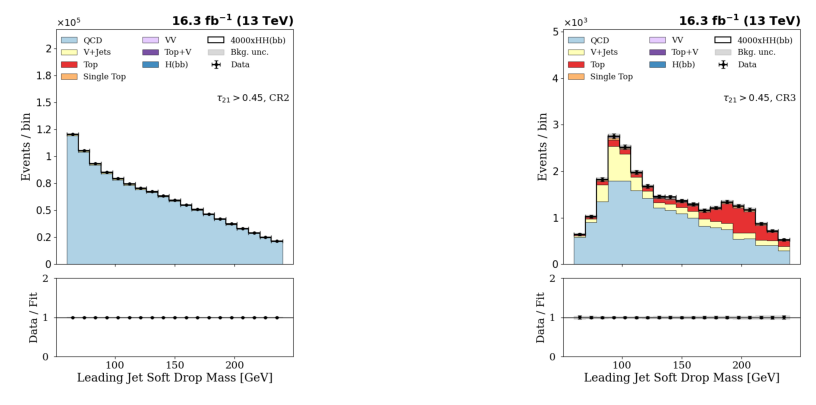

In [4]:
# Group some processes for plotting
VV_PROCS = {"ww_dijet", "wz_dijet", "zz_dijet"}
TOPV_PROCS = {"topw_dijet", "topz_dijet"}
STOP_PROCS = {"stopw_dijet", "stop_dijet"}
VJETS_PROCS = {"wjets_dijet", "zjets_dijet"}

color_dict = {
    "stop": {"name": "Single Top", "color": "#fdae61"},
    "topv": {"name": "Top+V", "color": "#6a3d9a"},
    "vv_dijet": {"name": "VV", "color": "#e4c6ff"},
    "higgs_dijet": {"name": "H(bb)", "color": "#2c7fb8"},
    "vjets_dijet": {"name": "V+Jets", "color": "#ffffb2"},
    "top_dijet": {"name": "Top", "color": "#e41a1c"},
    "dihiggs_dijet": {"name": "4000xHH(bb)", "color": "#e41a1c"},
}

canvas_label = {
    ("SR", "SR"): r"$\tau_{21} < 0.45$, SR",
    ("SR", "CR1"): r"$\tau_{21} < 0.45$, CR1",
    ("SR", "CR2"): r"$\tau_{21} < 0.45$, CR2",
    ("SR", "CR3"): r"$\tau_{21} < 0.45$, CR3",
    ("VR1", "SR"): r"$\tau_{21} > 0.45$, SR",
    ("VR1", "CR1"): r"$\tau_{21} > 0.45$, CR1",
    ("VR1", "CR2"): r"$\tau_{21} > 0.45$, CR2",
    ("VR1", "CR3"): r"$\tau_{21} > 0.45$, CR3",
    ("SR1", "SR"): r"$\tau_{21} < 0.45$, J2 m > 100 GeV, SR",
    ("SR1", "CR1"): r"$\tau_{21} < 0.45$, J2 m > 100 GeV, CR1",
    ("SR1", "CR2"): r"$\tau_{21} < 0.45$, J2 m > 100 GeV, CR2",
    ("SR1", "CR3"): r"$\tau_{21} < 0.45$, J2 m > 100 GeV, CR3",
    ("SR2", "SR"): r"$\tau_{21} < 0.45$, J2 m < 100 GeV, SR",
    ("SR2", "CR1"): r"$\tau_{21} < 0.45$, J2 m < 100 GeV, CR1",
    ("SR2", "CR2"): r"$\tau_{21} < 0.45$, J2 m < 100 GeV, CR2",
    ("SR2", "CR3"): r"$\tau_{21} < 0.45$, J2 m < 100 GeV, CR3",
    ("SR3", "SR"): r"$\tau_{21} < 0.45$, J2 m > 100 GeV, b-tag, SR",
    ("SR3", "CR1"): r"$\tau_{21} < 0.45$, J2 m > 100 GeV, b-tag, CR1",
    ("SR3", "CR2"): r"$\tau_{21} < 0.45$, J2 m > 100 GeV, b-tag, CR2",
    ("SR3", "CR3"): r"$\tau_{21} < 0.45$, J2 m > 100 GeV, b-tag, CR3",
}


def _set_fixed_math_yaxis(ax, ymax):
    # Try to fix the y-axis digits to keep all plots the same size
    if ymax <= 0:
        exponent = 0
    else:
        exponent = int(np.floor(np.log10(ymax)))

    scale = 10.0**exponent

    def _fmt(y, pos):
        val = y / scale
        if np.isclose(val, round(val)):
            s = f"{int(round(val))}"
        else:
            s = f"{val:.1f}".rstrip("0").rstrip(".")
        return rf"${s}$"

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(_fmt))
    ax.yaxis.offsetText.set_visible(False)

    ax.text(
        0.0,
        1.005,
        rf"$\times 10^{{{exponent}}}$",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=14,
    )


def plot_postfit(
    postfit_file,
    bin_edges,
    abcd_region="SR",
    region="SR",
    pred_type="NP",
    fit_type="fit_s",
):
    qcd_prefix = f"QCD_{region}_bin_"
    qcd_label = f"QCD_{region}"
    bin_edges = np.asarray(bin_edges, dtype=np.float64)
    n_bins_expected = len(bin_edges) - 1
    signal_scale = 1.0

    def _read_hist_values(obj, name="object"):
        try:
            return np.asarray(obj.values(), dtype=np.float64)
        except Exception as e:
            raise TypeError(f"Could not read histogram values from {name}: {e}")

    def _read_hist_errors(obj, name="object"):
        try:
            return np.asarray(obj.errors(), dtype=np.float64)
        except Exception as e:
            raise TypeError(f"Could not read histogram errors from {name}: {e}")

    def _read_data(obj):
        try:
            y = np.asarray(obj.values(), dtype=np.float64)
            try:
                err = np.asarray(obj.errors(), dtype=np.float64)
            except Exception:
                err = np.sqrt(np.clip(y, 0.0, None))
            return y, err, err
        except Exception:
            pass

        try:
            y = np.asarray(obj.member("fY"), dtype=np.float64)
            eyl = np.asarray(obj.member("fEYlow"), dtype=np.float64)
            eyh = np.asarray(obj.member("fEYhigh"), dtype=np.float64)
            return y, eyl, eyh
        except Exception:
            pass

        raise TypeError(f"Could not read data object of type {obj.classname}")

    def _group_processes(base, qcd_prefix, n_bins_expected):
        qcd_total = None
        proc_hists = {}
        skip = {"data_obs", "TotalBkg", "TotalSig", "TotalProcs"}
        signal_name_local = globals().get("signal_name", None)

        for key in base.keys():
            name = key.split(";")[0]
            if name in skip:
                continue

            obj = base[name]
            try:
                vals = _read_hist_values(obj, name)
            except Exception:
                continue

            if len(vals) != n_bins_expected:
                continue

            if qcd_total is None:
                qcd_total = np.zeros_like(vals)

            if name.startswith(qcd_prefix):
                qcd_total += vals
            elif signal_name_local is not None and name == signal_name_local:
                continue
            elif name in VV_PROCS:
                proc_hists["vv_dijet"] = (
                    proc_hists.get("vv_dijet", np.zeros_like(vals)) + vals
                )
            elif name in STOP_PROCS:
                proc_hists["stop"] = proc_hists.get("stop", np.zeros_like(vals)) + vals
            elif name in TOPV_PROCS:
                proc_hists["topv"] = proc_hists.get("topv", np.zeros_like(vals)) + vals
            elif name in VJETS_PROCS:
                proc_hists["vjets_dijet"] = (
                    proc_hists.get("vjets_dijet", np.zeros_like(vals)) + vals
                )
            else:
                proc_hists[name] = proc_hists.get(name, np.zeros_like(vals)) + vals

        if qcd_total is None:
            qcd_total = np.zeros(n_bins_expected, dtype=np.float64)

        return qcd_total, proc_hists, signal_name_local

    with uproot.open(postfit_file) as f:
        dirname = f"{region}_{abcd_region}_postfit"
        if dirname not in f:
            raise KeyError(f"Directory '{dirname}' not found in {postfit_file}")

        base = f[dirname]

        if "data_obs" not in base:
            raise KeyError(f"'data_obs' not found in {dirname}")
        if "TotalBkg" not in base:
            raise KeyError(f"'TotalBkg' not found in {dirname}")

        data_y, data_eyl, data_eyh = _read_data(base["data_obs"])
        bkg_vals = _read_hist_values(base["TotalBkg"], "TotalBkg")
        bkg_errs = _read_hist_errors(base["TotalBkg"], "TotalBkg")

        if fit_type == "fit_s" and "TotalSig" in base:
            sig_vals = _read_hist_values(base["TotalSig"], "TotalSig")
        else:
            sig_vals = np.zeros_like(bkg_vals)

        if len(bkg_vals) != n_bins_expected:
            raise ValueError(
                f"Bin mismatch: plotting bin_edges imply {n_bins_expected} bins, "
                f"but TotalBkg has {len(bkg_vals)} bins in {dirname}"
            )
        if len(data_y) != n_bins_expected:
            raise ValueError(
                f"Bin mismatch: data_obs has {len(data_y)} bins but expected {n_bins_expected}"
            )

        qcd_total, proc_hists, signal_name_local = _group_processes(
            base, qcd_prefix, n_bins_expected
        )

    sorted_mc = dict(sorted(proc_hists.items(), key=lambda x: x[1].sum(), reverse=True))
    ordered_hists = {qcd_label: qcd_total, **sorted_mc}

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = bin_edges[1:] - bin_edges[:-1]
    data_x_phys = bin_centers
    data_exl_phys = bin_widths / 2.0
    data_exh_phys = bin_widths / 2.0
    fit_vals = bkg_vals + sig_vals if fit_type == "fit_s" else bkg_vals

    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, gridspec_kw={"height_ratios": [3, 1]}, figsize=(6, 8)
    )

    default_color_cycle = itertools.cycle(plt.cm.tab10.colors)
    bottom = np.zeros_like(bkg_vals)

    for name, vals in ordered_hists.items():
        if name in color_dict:
            color = color_dict[name]["color"]
            label = color_dict[name]["name"]
        elif name == qcd_label:
            color = "#a6cee3"
            label = "QCD"
        else:
            color = next(default_color_cycle)
            label = name

        ax1.hist(
            bin_edges[:-1],
            bins=bin_edges,
            weights=vals,
            bottom=bottom,
            histtype="stepfilled",
            color=color,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label=label,
        )
        bottom += vals

    if fit_type == "fit_s":
        if (
            signal_name_local is not None
            and signal_name_local in color_dict
            and "HH" not in color_dict[signal_name_local]["name"]
        ):
            histtype = "stepfilled"
            color = color_dict[signal_name_local]["color"]
        else:
            histtype = "step"
            color = "black"

        ax1.hist(
            bin_edges[:-1],
            bins=bin_edges,
            weights=signal_scale * sig_vals,
            bottom=bkg_vals,
            histtype=histtype,
            edgecolor="black",
            linewidth=1.5,
            color=color,
            label=f"{color_dict[signal_name_local]['name']}"
            if signal_name_local in color_dict
            else "Signal",
        )

    ax1.fill_between(
        np.repeat(bin_edges, 2)[1:-1],
        np.repeat(np.clip(bkg_vals - bkg_errs, 0.0, None), 2),
        np.repeat(bkg_vals + bkg_errs, 2),
        color="gray",
        alpha=0.3,
        label="Bkg. unc.",
    )

    ax1.errorbar(
        data_x_phys,
        data_y,
        xerr=[data_exl_phys, data_exh_phys],
        yerr=[data_eyl, data_eyh],
        fmt="ko",
        ms=4,
        capsize=3,
        label="Data",
        zorder=10,
    )

    ax1.set_ylabel("Events / bin", fontsize=17)

    ymax = max(
        np.max(data_y) if len(data_y) else 0.0,
        np.max(bkg_vals + bkg_errs) if len(bkg_vals) else 0.0,
        np.max(fit_vals) if len(fit_vals) else 0.0,
        np.max(bkg_vals + signal_scale * sig_vals) if fit_type == "fit_s" else 0.0,
    )
    ax1.set_ylim(0, 1.8 * ymax if ymax > 0 else 1.0)
    _set_fixed_math_yaxis(ax1, ax1.get_ylim()[1])

    ax1.text(
        1.0,
        1.005,
        r"$\mathbf{16.3\ fb^{-1}\ (13\ TeV)}$",
        ha="right",
        va="bottom",
        fontsize=18,
        transform=ax1.transAxes,
    )

    loc = "upper right"
    leg = ax1.legend(
        fontsize=12,
        ncols=3,
        loc=loc,
        framealpha=1.0,
        edgecolor="black",
    )
    leg.set_zorder(10)

    fig.canvas.draw()
    leg_bb = leg.get_window_extent().transformed(ax1.transAxes.inverted())
    label_text = canvas_label.get((region, abcd_region), f"{region}, {abcd_region}")

    if loc == "upper left":
        txt_x, txt_ha = leg_bb.x0, "left"
    else:
        txt_x, txt_ha = leg_bb.x1, "right"

    ax1.text(
        txt_x,
        leg_bb.y0,
        label_text,
        ha=txt_ha,
        va="top",
        fontsize=14,
        transform=ax1.transAxes,
        bbox=dict(facecolor="white", edgecolor="none", alpha=1.0, pad=2),
        zorder=11,
    )

    mask = fit_vals > 0
    ratio = np.zeros_like(fit_vals)
    ratio_eyl = np.zeros_like(fit_vals)
    ratio_eyh = np.zeros_like(fit_vals)
    ratio_unc = np.zeros_like(fit_vals)

    ratio[mask] = data_y[mask] / fit_vals[mask]
    ratio_eyl[mask] = data_eyl[mask] / fit_vals[mask]
    ratio_eyh[mask] = data_eyh[mask] / fit_vals[mask]
    ratio_unc[mask] = bkg_errs[mask] / fit_vals[mask]

    ax2.axhline(1, color="black", lw=1)
    ax2.fill_between(
        np.repeat(bin_edges, 2)[1:-1],
        np.repeat(1 - ratio_unc, 2),
        np.repeat(1 + ratio_unc, 2),
        color="gray",
        alpha=0.3,
    )
    ax2.errorbar(
        data_x_phys[mask],
        ratio[mask],
        yerr=[ratio_eyl[mask], ratio_eyh[mask]],
        fmt="ko",
        ms=4,
        capsize=3,
    )
    ax2.set_ylabel("Data / Fit", fontsize=16)

    if observable == "dimass":
        ax2.set_xlabel("Dijet Invariant Mass [GeV]", fontsize=17)
    else:
        ax2.set_xlabel("Leading Jet Soft Drop Mass [GeV]", fontsize=17)

    ax2.set_ylim(0.0, 2.0)

    ax2.tick_params(axis="y", pad=8)
    ax1.tick_params(axis="x", pad=6)
    ax1.tick_params(axis="both", labelsize=15)
    ax2.tick_params(axis="both", labelsize=15)

    plt.subplots_adjust(left=0.16, right=0.98, top=0.95, bottom=0.10, hspace=0.09)
    plt.savefig(
        f"plots/postfit_{pred_type}_{region}_{abcd_region}_{fit_type}_{size}_{observable}_{tag}.pdf"
    )
    fig.canvas.draw()
    plt.close(fig)
    return fig
    # plt.show()


postfit_file = (
    f"{datacard_path}/postfit_{pred_type}_shapes_bkg_{size}_{observable}_{tag}.root"
)

figs = []

for region in datacard_regions:
    for abcd_region in ["SR", "CR1", "CR2", "CR3"]:
        figs.append(
            plot_postfit(
                postfit_file=postfit_file,
                bin_edges=bins[region],
                abcd_region=abcd_region,
                region=region,
                pred_type=pred_type,
                fit_type="fit_b",
            )
        )

postfit_file = (
    f"{datacard_path}/postfit_{pred_type}_shapes_sig_{size}_{observable}_{tag}.root"
)
for region in datacard_regions:
    for abcd_region in ["SR", "CR1", "CR2", "CR3"]:
        figs.append(
            plot_postfit(
                postfit_file=postfit_file,
                bin_edges=bins[region],
                abcd_region=abcd_region,
                region=region,
                pred_type=pred_type,
                fit_type="fit_s",
            )
        )

# display side-by-side
for i in range(0, len(figs), 2):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(figs[i].canvas.buffer_rgba())
    plt.axis("off")

    if i + 1 < len(figs):
        plt.subplot(1, 2, 2)
        plt.imshow(figs[i + 1].canvas.buffer_rgba())
        plt.axis("off")

    plt.show()